In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import torch
import slicetca

import utils as ut
import plot as pt
plt.rcParams.update({'font.size': 12,
                     'axes.spines.right': False,
                     'axes.spines.top':   False,
                     'legend.frameon':    False,})

%load_ext autoreload
%autoreload 2

/Users/ag1880/github-repos/Milstein-Lab/CA1-interneuron-GLM/utils.py:7: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


# Synthetic data

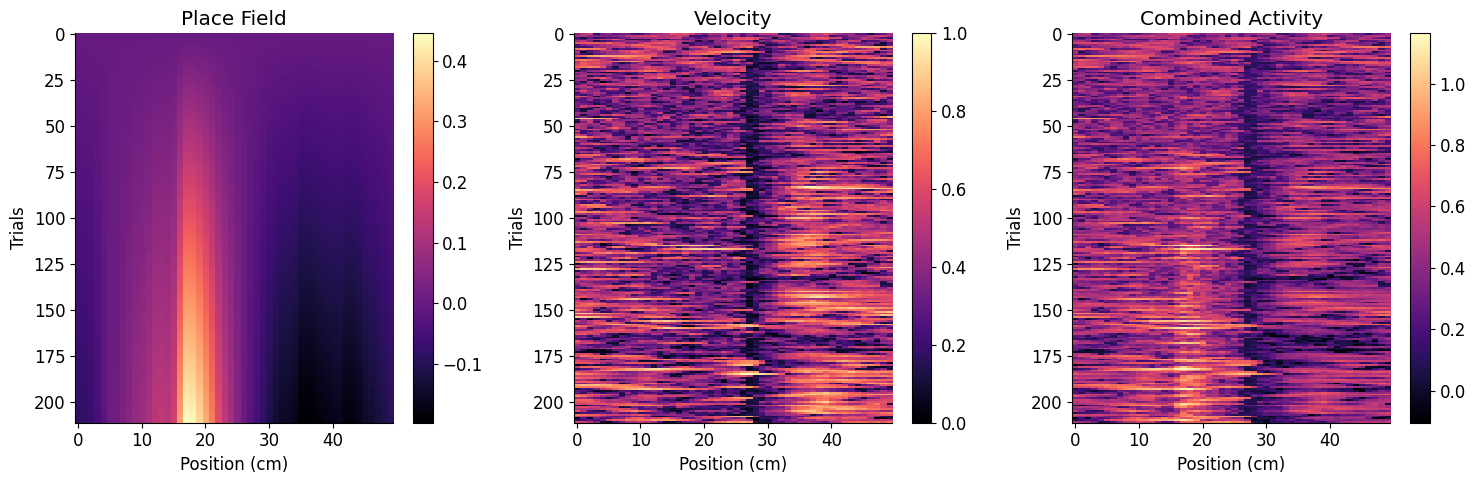

In [443]:
filename = "SSTindivsomata_GLM"
# filename = "NDNFindivsomata_GLM"
# filename = "EC_GLM"

filepath = os.path.join("datasets", filename+".mat")
activity_dict, factors_dict = ut.preprocess_data(filepath)

animal = 'animal_1'
velocity = factors_dict[animal]['Velocity']

activity, place_field, velocity_component, noise = ut.get_synthetic_data(activity_dict, velocity, 
                                                                        place_field_type='positive_ramp', place_field_scale=-1, place_field_shift=-10, 
                                                                        velocity_weight_type='flat', velocity_weight=1, velocity_power=1, 
                                                                        noise_scale=0)

fig, ax = plt.subplots(1,3, figsize=(15,5))

im = ax[0].imshow(place_field.T, interpolation='nearest', aspect='auto', cmap='magma')
cbar = fig.colorbar(im, ax=ax[0])
ax[0].set_title('Place Field')
ax[0].set_xlabel('Position (cm)')
ax[0].set_ylabel('Trials')

im = ax[1].imshow(velocity.T, interpolation='nearest', aspect='auto', cmap='magma')
cbar = fig.colorbar(im, ax=ax[1])
ax[1].set_title('Velocity')
ax[1].set_xlabel('Position (cm)')
ax[1].set_ylabel('Trials')

im = ax[2].imshow(activity.T, interpolation='nearest', aspect='auto', cmap='magma')
cbar = fig.colorbar(im, ax=ax[2])
ax[2].set_title('Combined Activity')
ax[2].set_xlabel('Position (cm)')
ax[2].set_ylabel('Trials')
plt.tight_layout()
plt.show()

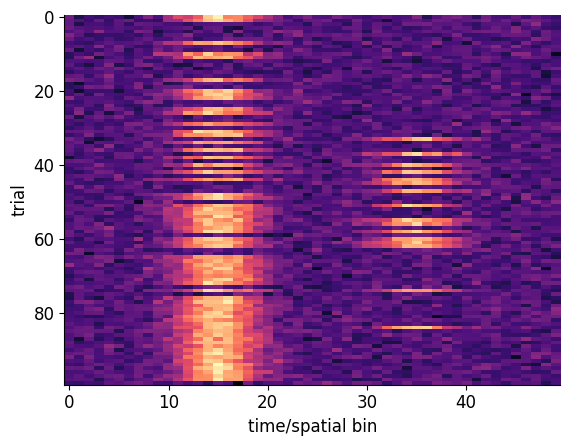

In [102]:
num_trials = 100
num_timebins = 50
ideal_cell = torch.zeros(num_trials, 1, num_timebins)

# Add gaussian place field
def place_field(x, mu, sigma):
    return torch.exp(-(x - mu)**2 / (2 * sigma**2))

field1 = place_field(torch.arange(num_timebins), mu=15, sigma=3)
field2 = place_field(torch.arange(num_timebins), mu=35, sigma=3)

# Sigmoid function for probability
def sigmoid(x, slope=1, offset=0):
    return 1 / (1 + np.exp(-slope * (x - offset)))

def bell_curve(x, mu, sigma):
    return np.exp(-(x - mu)**2 / (2 * sigma**2))

# Generate probabilities for each trial
x = np.linspace(-6, 6, num_trials)
probabilities1 = sigmoid(x, slope=0.5, offset=-2)
probabilities2 = bell_curve(x, mu=0, sigma=2)*0.5

# Add place fields to a random subset of trials based on probabilities
for i in range(num_trials):
    express_field1 = np.random.choice([0, 1], p=[1-probabilities1[i], probabilities1[i]])
    express_field2 = np.random.choice([0, 1], p=[1-probabilities2[i], probabilities2[i]])
    ideal_cell[i] += express_field1*field1 + express_field2*field2

# Add noise
ideal_cell += torch.randn(num_trials, 1, num_timebins) * 0.1 

plt.imshow(ideal_cell[:, 0, :], interpolation='nearest', aspect='auto', cmap='magma')
plt.xlabel('time/spatial bin')
plt.ylabel('trial')
plt.show()

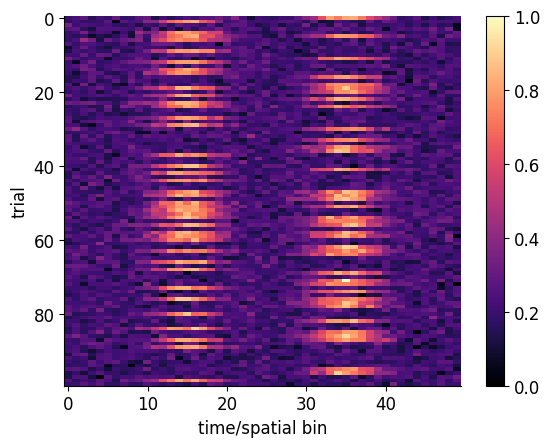

In [123]:
num_trials = 100
num_timebins = 50
ideal_cell = torch.zeros(num_trials,1,num_timebins)

# Add gaussian place field
def place_field(x, mu, sigma):
    return torch.exp(-(x - mu)**2 / (2 * sigma**2))

field1 = place_field(torch.arange(num_timebins), mu=15, sigma=3)
field2 = place_field(torch.arange(num_timebins), mu=35, sigma=3)

# Add place fields to a random subset of trials
field1_idx = torch.randint(0, num_trials, (num_trials//2,))
ideal_cell[field1_idx] += field1
field2_idx = torch.randint(0, num_trials, (num_trials//2,))
ideal_cell[field2_idx] += field2

# Add noise
ideal_cell += torch.randn(num_trials,1,num_timebins) * 0.1 


ideal_cell = (ideal_cell - ideal_cell.min()) / (ideal_cell.max() - ideal_cell.min())

im = plt.imshow(ideal_cell[:,0,:], interpolation='nearest', aspect='auto', cmap='magma')
cbar = plt.colorbar(im)
plt.xlabel('time/spatial bin')
plt.ylabel('trial')
plt.show()

The model converged. Loss: 0.0032229984644800425 :   7%|▋         | 1110/15000 [00:02<00:33, 410.65it/s]


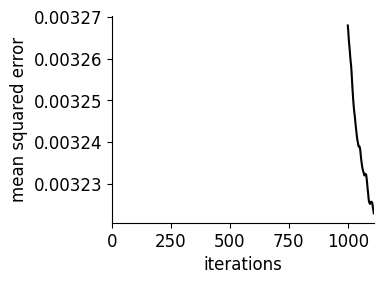

In [124]:
#### Run sliceTCA ####
device = ('cuda' if torch.cuda.is_available() else 'cpu')
neural_data_tensor = ideal_cell

components, model = slicetca.decompose(neural_data_tensor,
                                       number_components=(3,0,0), # (trials, neurons, time bins)
                                       positive=True,
                                       learning_rate=2*10**-3,
                                       min_std=10**-5,
                                       max_iter=15_000,
                                       seed=0)

plt.figure(figsize=(4,3), dpi=100)
plt.plot(np.arange(1000,len(model.losses)), model.losses[1000:], 'k')
plt.xlabel('iterations')
plt.ylabel('mean squared error')
plt.xlim(0,len(model.losses))
plt.tight_layout()

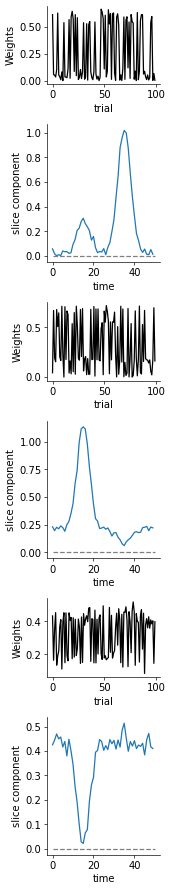

In [125]:
# sort the neurons (in the trial slices) according to their peak activity in the first slice.
# neuron_sorting_peak_time = np.argsort(np.argmax(components[0][1][0], axis=1))
axes = slicetca.plot(model,
              variables=('trial', 'neuron', 'time'),
            #   ticks=(None, None, np.linspace(0,50,3)), # we only want to modify the time ticks
            #   tick_labels=(None, None, np.linspace(0,50,3)),
            #   sorting_indices=(None, neuron_sorting_peak_time, None),
              quantile=0.99)

In [126]:
w1 = model.vectors[0][0][0,:].detach()
f1 = model.vectors[0][1][0,0,:].detach()
w2 = model.vectors[0][0][1,:].detach()
f2 = model.vectors[0][1][1,0,:].detach()
w3 = model.vectors[0][0][2,:].detach()
f3 = model.vectors[0][1][2,0,:].detach()
# w4 = model.vectors[0][0][3,:].detach()
# f4 = model.vectors[0][1][3,0,:].detach()

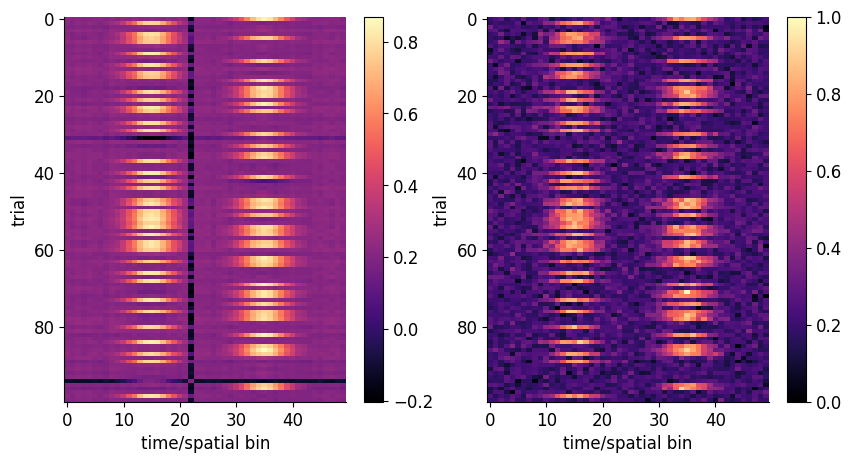

reconstruction MSE loss: 0.0059456960298120975


In [127]:
recon = torch.outer(w1,f1) + torch.outer(w2,f2) + torch.outer(w3,f3) #+ torch.outer(w4,f4)
# recon = model.construct().numpy(force=True)[:,0,:]

fig, axes = plt.subplots(1,2, figsize=(10,5))
ax = axes[0]
im = ax.imshow(recon, interpolation='nearest', aspect='auto', cmap='magma')
cbar = plt.colorbar(im, ax=ax)
ax.set_xlabel('time/spatial bin')
ax.set_ylabel('trial')

ax = axes[1]
original = ideal_cell[:,0,:]
im = ax.imshow(original, interpolation='nearest', aspect='auto', cmap='magma')
cbar = plt.colorbar(im, ax=ax)
ax.set_xlabel('time/spatial bin')
ax.set_ylabel('trial')
plt.show()

recontruction_loss = torch.mean((original - recon)**2)
print(f'reconstruction MSE loss: {recontruction_loss.item()}')

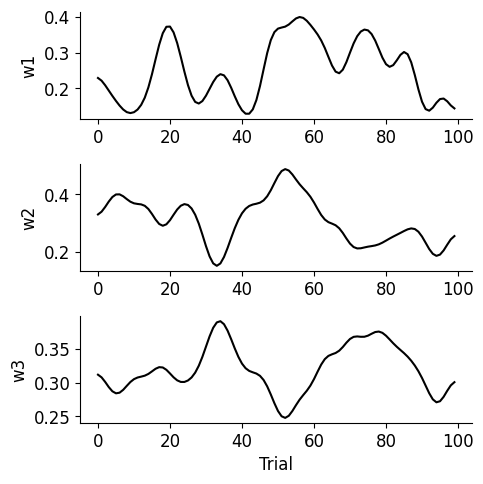

In [128]:
w1 = model.vectors[0][0][0,:].detach().numpy()
w2 = model.vectors[0][0][1,:].detach().numpy()
w3 = model.vectors[0][0][2,:].detach().numpy()

# Smooth the weight vectors
import scipy.ndimage as spnd
sigma = 3
w1_smooth = spnd.gaussian_filter1d(w1, sigma=sigma, axis=-1)
w2_smooth = spnd.gaussian_filter1d(w2, sigma=sigma, axis=-1)
w3_smooth = spnd.gaussian_filter1d(w3, sigma=sigma, axis=-1)

fig, ax = plt.subplots(3, 1, figsize=(5, 5))
ax[0].plot(w1_smooth, color='k')
ax[0].set_ylabel('w1')
ax[1].plot(w2_smooth, color='k')
ax[1].set_ylabel('w2')
ax[2].plot(w3_smooth, color='k')
ax[2].set_ylabel('w3')
ax[2].set_xlabel('Trial')
plt.tight_layout()
plt.show()

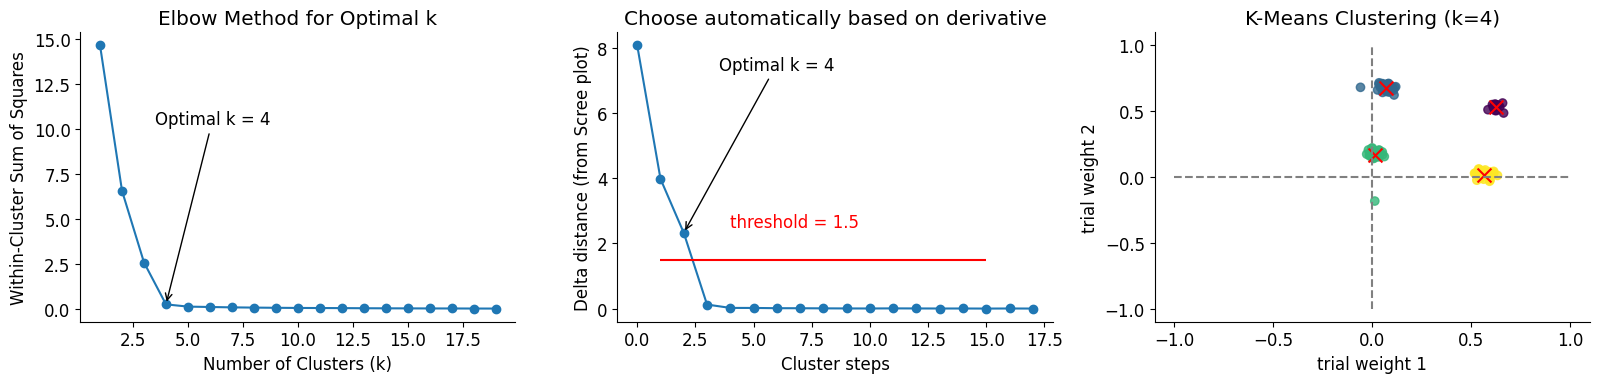

In [129]:
# model.vectors[0] # 0:trial, 1:cell, 2:timebin

w1 = model.vectors[0][0][0,:].detach().numpy()
w2 = model.vectors[0][0][1,:].detach().numpy()

# # Smooth the weight vectors
# import scipy.ndimage as spnd
# sigma = 1
# w1 = spnd.gaussian_filter1d(w1, sigma=sigma, axis=-1)
# w2 = spnd.gaussian_filter1d(w2, sigma=sigma, axis=-1)


from sklearn.cluster import KMeans
X = np.vstack((w1, w2)).T

# Determine the optimal number of clusters using the elbow method
distances = []
k_values = range(1, 20)
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
    kmeans.fit(X)
    distances.append(kmeans.inertia_)

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
# Plot Scree (Elbow) Plot
ax[0].plot(k_values, distances, marker='o', linestyle='-')
ax[0].set_xlabel("Number of Clusters (k)")
ax[0].set_ylabel("Within-Cluster Sum of Squares")
ax[0].set_title("Elbow Method for Optimal k")

# Apply k-means clustering with optimal k (set manually or from elbow plot)
diff = -np.diff(distances)
threshold = 1.5
optimal_k = np.where(diff < threshold)[0][0] + 1
# optimal_k = 3  # Change this based on the elbow method
ax[0].annotate(f"Optimal k = {optimal_k}", xy=(optimal_k, distances[optimal_k-1]), xytext=(optimal_k-0.5, distances[optimal_k-1] + 10), arrowprops=dict(facecolor='red', arrowstyle='->'))
kmeans = KMeans(n_clusters=optimal_k, random_state=0, n_init=10).fit(X)

ax[1].plot(diff, '-o')
ax[1].annotate(f"Optimal k = {optimal_k}", xy=(optimal_k-2, diff[optimal_k-2]), xytext=(optimal_k-0.5, diff[optimal_k-2] + 5), arrowprops=dict(facecolor='red', arrowstyle='->'))
ax[1].hlines(threshold, 1, 15, color='red')
ax[1].text(optimal_k, threshold+1, f"threshold = {threshold}", color='red')
ax[1].set_xlabel('Cluster steps')
ax[1].set_ylabel('Delta distance (from Scree plot)')
ax[1].set_title('Choose automatically based on derivative')


# Scatter plot of clustered points
ax[2].scatter(w1, w2, c=kmeans.labels_, cmap="viridis", alpha=0.8)
ax[2].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
              c='red', marker='x', s=100, label='Cluster Centers')
ax[2].set_xlabel("trial weight 1")
ax[2].set_ylabel("trial weight 2")
ax[2].set_title(f"K-Means Clustering (k={optimal_k})")
ax[2].vlines(x=0, ymin=min(-1,w2.min()), ymax=max(1,w2.max()), color='gray', linestyle='--')
ax[2].hlines(y=0, xmin=min(-1,w1.min()), xmax=max(1,w1.max()), color='gray', linestyle='--')

plt.tight_layout()
plt.show()


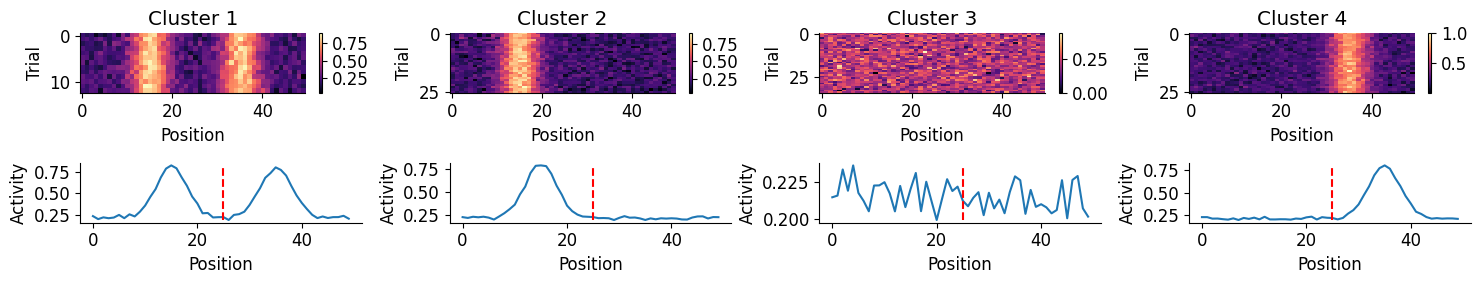

In [130]:
num_neurons = neural_data_tensor.shape[1]
if num_neurons < 20:
    fig, ax = plt.subplots(2*num_neurons, optimal_k, figsize=(15, 3*num_neurons))
    for n in range(num_neurons):
        for k in range(optimal_k):
            cluster_trials = neural_data_tensor[kmeans.labels_==k, n, :]
            im = ax[2*n, k].imshow(cluster_trials, aspect='auto', cmap='magma', interpolation='nearest')
            cbar = fig.colorbar(im, ax=ax[2*n, k])
            ax[2*n, k].set_title(f'Cluster {k+1}')
            ax[2*n, k].set_xlabel('Position')
            ax[2*n, k].set_ylabel('Trial')
            ax[2*n+1, k].plot(cluster_trials.mean(axis=0))
            ax[2*n+1, k].set_xlabel('Position')
            ax[2*n+1, k].set_ylabel('Activity')
            ax[2*n+1, k].vlines(25, cluster_trials.mean(axis=0).min(), cluster_trials.mean(axis=0).max(), color='r', linestyle='--')

    plt.tight_layout()
    plt.show()


# Real Data

In [56]:
filename = "SSTindivsomata_GLM"
# filename = "NDNFindivsomata_GLM"
# filename = "EC_GLM"

filepath = os.path.join("datasets", filename+".mat")
activity_dict, factors_dict = ut.preprocess_data(filepath)
filtered_factors_dict = ut.subset_variables_from_data(factors_dict, variables_to_keep=["Velocity"])

GLM_params, predicted_activity_dict = ut.fit_GLM_population(filtered_factors_dict, activity_dict, quintile=None, regression='linear')
residual_activity_dict = ut.get_residual_activity_dict(activity_dict, predicted_activity_dict)

animal = 'animal_2'
neural_data = ut.get_animal_neural_tensor(residual_activity_dict, animal=animal)

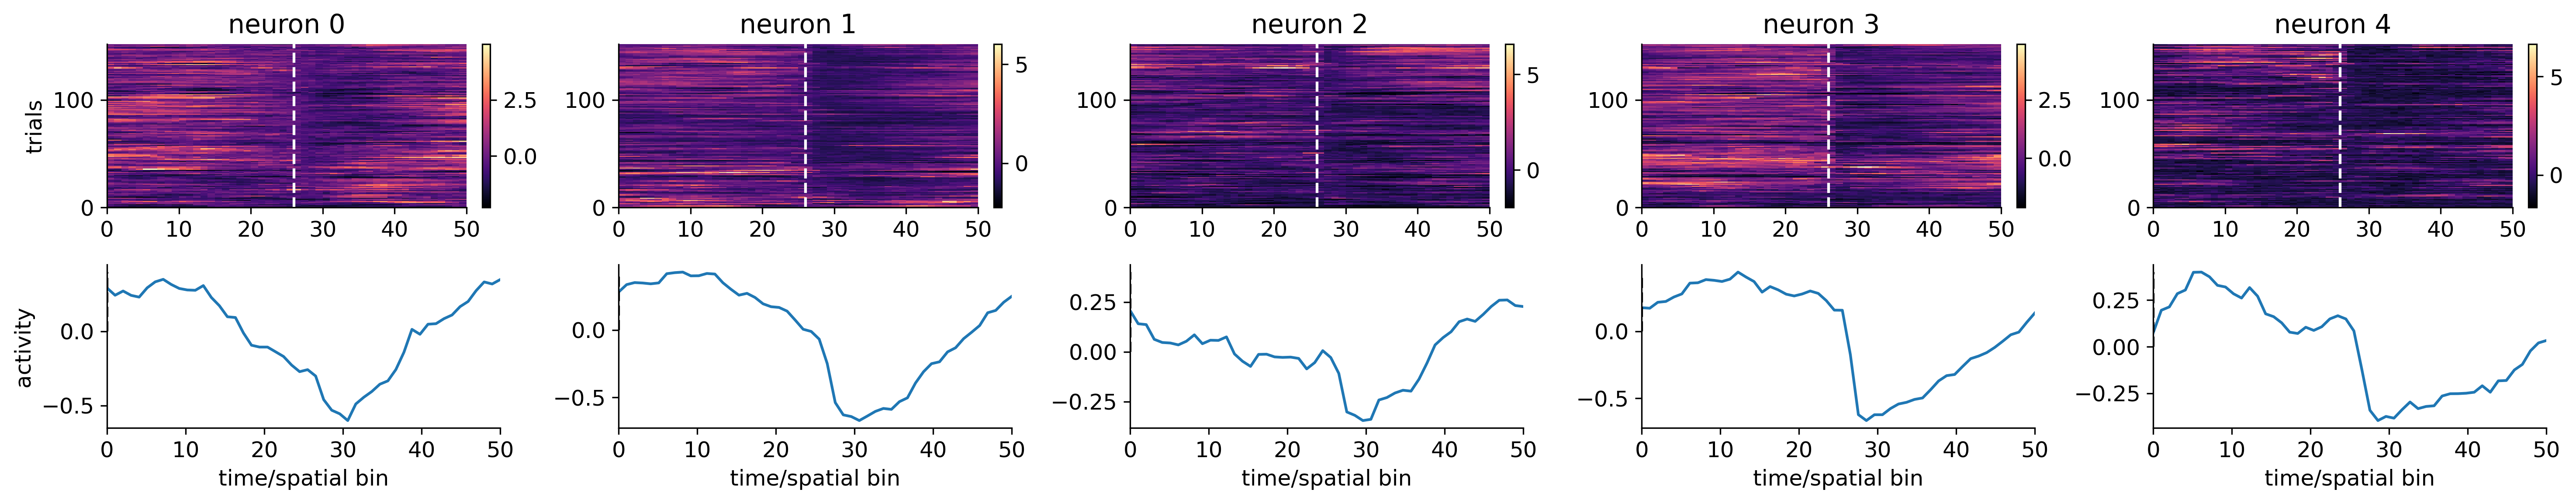

In [57]:
#### Plot raw data ####
n = 0
neurons = np.arange(n*5,n*5+5)

# EC data:
# neurons = [5,19,23,52,95,137,180] # Animal 1, super nice: 95
# neurons = [] # Animal 2
# neurons = [18,19,53,57,60,75,79,95,152] # Animal 3
# neurons = [0,1,4,6,9,12,15,26,36,39,45,57] # Animal 4 
# neurons = [3,5,7,23] # Animal 5

plt.figure(figsize=(20,4), dpi=300)
# heat maps sorted by target angle for three example neurons
for ni,n in enumerate(neurons):
    plt.subplot(2,len(neurons),ni+1)
    im = plt.imshow(neural_data[:,n], aspect='auto', extent=[0,50, 0, len(neural_data)], cmap='magma', origin='lower', interpolation='none')
    # im = plt.imshow(neural_data[:,n], aspect='auto', vmin=0, vmax=0.7, extent=[0,50, 0, len(neural_data)], cmap='magma', origin='lower', interpolation='none')
    cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.vlines(26, 0, len(neural_data), colors='w', linestyles='--')
    if ni==0: plt.ylabel('trials')
    plt.title('neuron ' + str(n))

# condition-averaged, scaled & smoothed PSTHs
for ni,n in enumerate(neurons):
    plt.subplot(2,len(neurons),len(neurons)+ni+1)
    plt.plot(np.linspace(0,50,50), np.mean(neural_data[:,n], axis=0), '-')
    plt.plot([0,0], [0,.4], 'k--')
    if ni==0: plt.ylabel('activity')
    plt.xlim([0,50])
    plt.xlabel('time/spatial bin')
plt.tight_layout()

torch.Size([152, 1, 50])


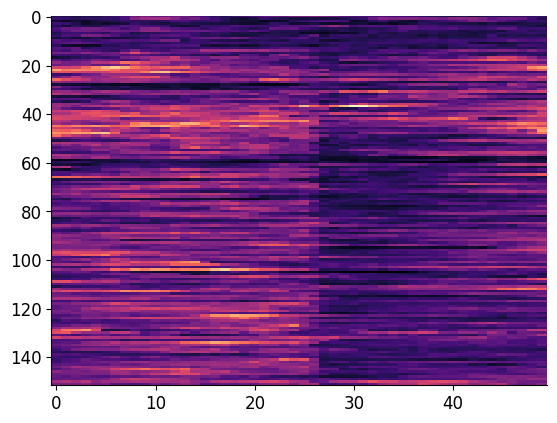

In [131]:
cell_nr = 3
neural_data_tensor = torch.tensor(neural_data[:,cell_nr,:] / neural_data[:,cell_nr,:].std())
plt.imshow(neural_data_tensor, interpolation='none', aspect='auto', cmap='magma')

neural_data_tensor = neural_data_tensor.unsqueeze(1)
print(neural_data_tensor.shape)

In [132]:
# neuron_idx = [18,19,53,57,60,75,79,95,152] # Animal 3
# neural_data_tensor = torch.tensor(neural_data[:,:,:] / neural_data[:,:,:].std())

The model converged. Loss: 0.2605536937854871 :  27%|██▋       | 4111/15000 [00:08<00:21, 498.57it/s]


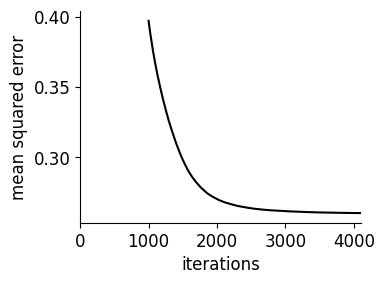

In [133]:
#### Run sliceTCA ####
device = ('cuda' if torch.cuda.is_available() else 'cpu')

# neural_data_tensor = torch.tensor(neural_data, device=device, dtype=torch.float32)
# # neural_data_tensor = neural_data_tensor/neural_data_tensor.std() # rescale data so it has similar magnitude as the initial weights
# print(neural_data_tensor.shape)

components, model = slicetca.decompose(neural_data_tensor,
                                       number_components=(3,0,0), # (trials, neurons, time bins)
                                       positive=False,
                                       learning_rate=1*10**-3,
                                       min_std=10**-5,
                                       max_iter=15_000,
                                       seed=0)

plt.figure(figsize=(4,3), dpi=100)
plt.plot(np.arange(1000,len(model.losses)), model.losses[1000:], 'k')
plt.xlabel('iterations')
plt.ylabel('mean squared error')
plt.xlim(0,len(model.losses))
plt.tight_layout()

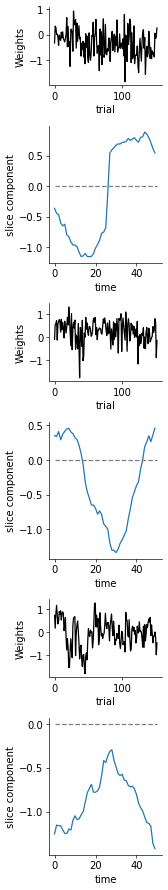

In [134]:
# sort the neurons (in the trial slices) according to their peak activity in the first slice.
neuron_sorting_peak_time = np.argsort(np.argmax(components[0][1][0], axis=1))

axes = slicetca.plot(model,
              variables=('trial', 'neuron', 'time'),
            #   ticks=(None, None, np.linspace(0,50,3)), # we only want to modify the time ticks
            #   tick_labels=(None, None, np.linspace(0,50,3)),
              sorting_indices=(None, neuron_sorting_peak_time, None),
              quantile=0.99)

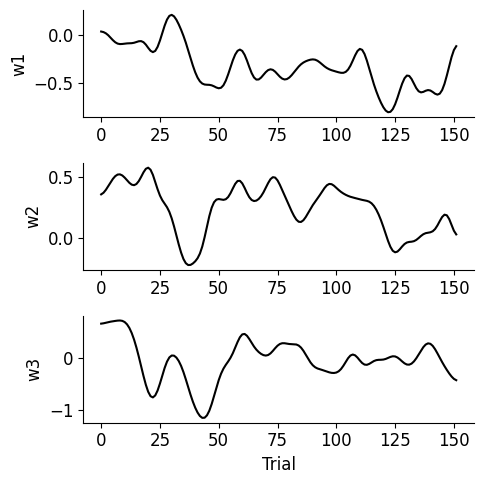

In [84]:
w1 = model.vectors[0][0][0,:].detach().numpy()
w2 = model.vectors[0][0][1,:].detach().numpy()
w3 = model.vectors[0][0][2,:].detach().numpy()

# Smooth the weight vectors
import scipy.ndimage as spnd
sigma = 3
w1_smooth = spnd.gaussian_filter1d(w1, sigma=sigma, axis=-1)
w2_smooth = spnd.gaussian_filter1d(w2, sigma=sigma, axis=-1)
w3_smooth = spnd.gaussian_filter1d(w3, sigma=sigma, axis=-1)

fig, ax = plt.subplots(3, 1, figsize=(5, 5))
ax[0].plot(w1_smooth, color='k')
ax[0].set_ylabel('w1')
ax[1].plot(w2_smooth, color='k')
ax[1].set_ylabel('w2')
ax[2].plot
ax[2].plot(w3_smooth, color='k')
ax[2].set_ylabel('w3')
ax[2].set_xlabel('Trial')
plt.tight_layout()
plt.show()


/var/folders/q9/g15z8pxs2fd8tgyd9ggfv1c8x5w4qx/T/ipykernel_90850/3240749825.py:65: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


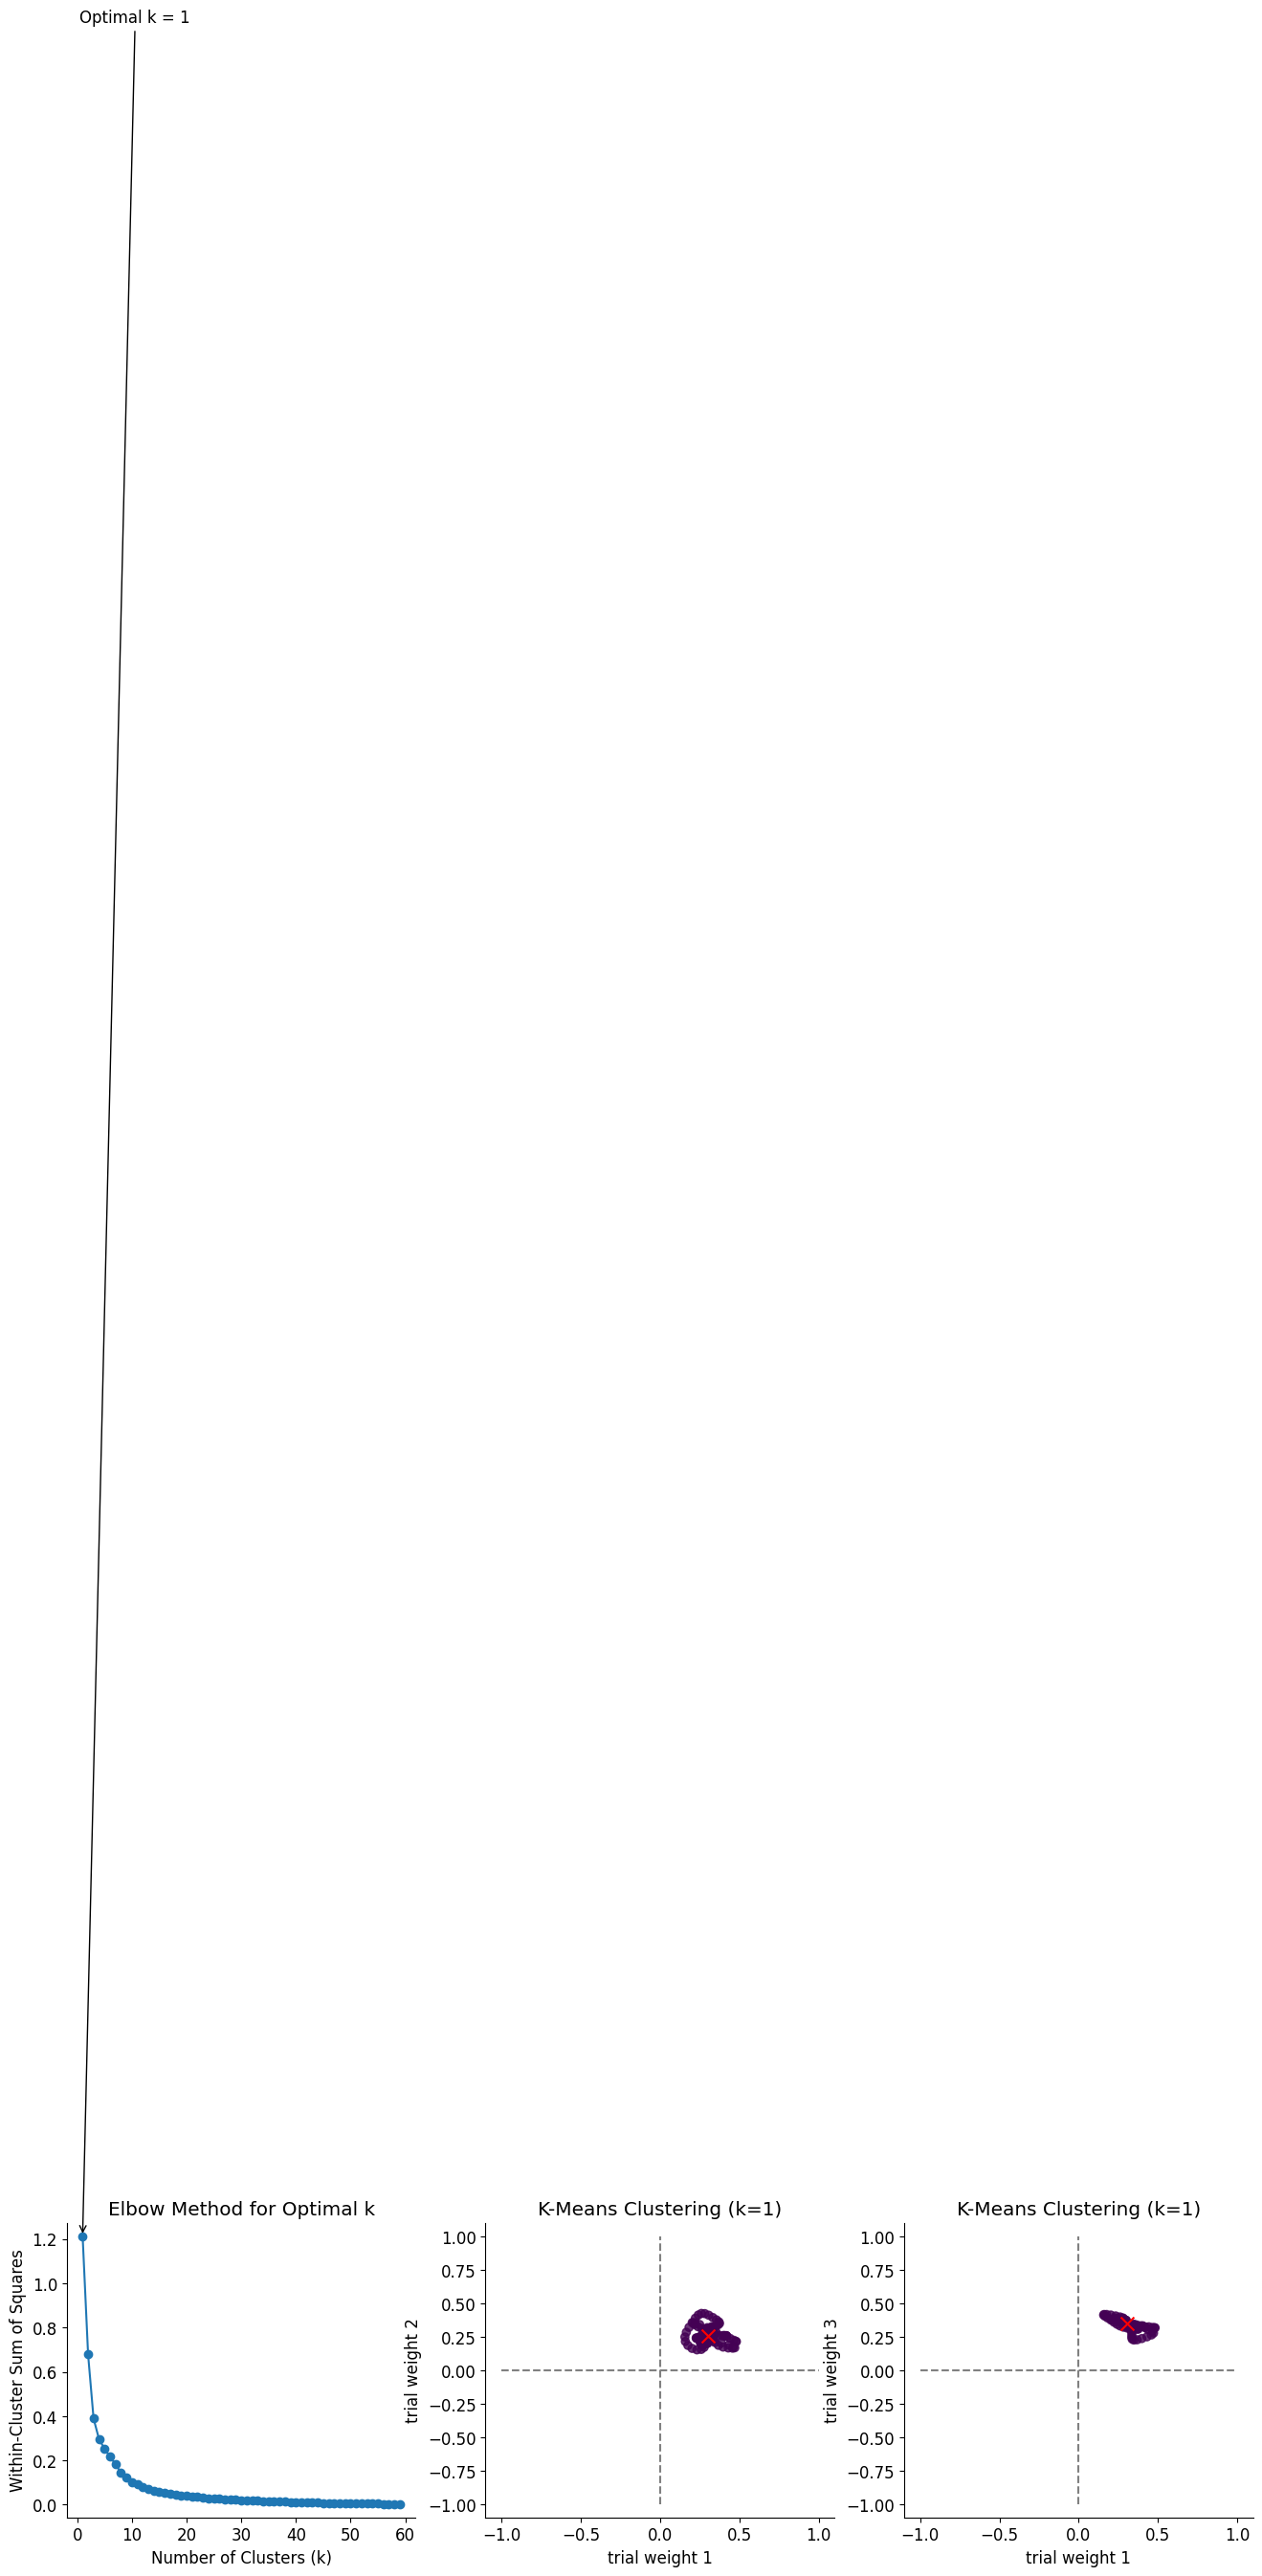

In [119]:
# model.vectors[0] # 0:trial, 1:cell, 2:timebin

w1 = model.vectors[0][0][0,:].detach().numpy()
w2 = model.vectors[0][0][1,:].detach().numpy()
w3 = model.vectors[0][0][2,:].detach().numpy()

import scipy.ndimage as spnd
sigma = 3
w1 = spnd.gaussian_filter1d(w1, sigma=sigma, axis=-1)
w2 = spnd.gaussian_filter1d(w2, sigma=sigma, axis=-1)
w3 = spnd.gaussian_filter1d(w3, sigma=sigma, axis=-1)

from sklearn.cluster import KMeans
# X = np.vstack((w1, w2)).T
X = np.vstack((w1, w2, w3)).T

# Determine the optimal number of clusters using the elbow method
distances = []
k_values = range(1, 60)
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
    kmeans.fit(X)
    distances.append(kmeans.inertia_)

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
# Plot Scree (Elbow) Plot
ax[0].plot(k_values, distances, marker='o', linestyle='-')
ax[0].set_xlabel("Number of Clusters (k)")
ax[0].set_ylabel("Within-Cluster Sum of Squares")
ax[0].set_title("Elbow Method for Optimal k")

# Apply k-means clustering with optimal k (set manually or from elbow plot)
diff = -np.diff(distances)
threshold = 1.5
optimal_k = np.where(diff < threshold)[0][0] + 1

# optimal_k = 10  # Change this based on the elbow method
if optimal_k > 10:
    print(f"Optimal k = {optimal_k}")
    print("Too many clusters to plot! Setting a cap at 10")
    optimal_k = 10

ax[0].annotate(f"Optimal k = {optimal_k}", xy=(optimal_k, distances[optimal_k-1]), xytext=(optimal_k-0.5, distances[optimal_k-1] + 10), arrowprops=dict(facecolor='red', arrowstyle='->'))
kmeans = KMeans(n_clusters=optimal_k, random_state=0, n_init=10).fit(X)

# Scatter plot of clustered points
ax[1].scatter(w1, w2, c=kmeans.labels_, cmap="viridis", alpha=0.8)
ax[1].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
              c='red', marker='x', s=100, label='Cluster Centers')
ax[1].set_xlabel("trial weight 1")
ax[1].set_ylabel("trial weight 2")
ax[1].set_title(f"K-Means Clustering (k={optimal_k})")
ax[1].vlines(x=0, ymin=min(-1,w2.min()), ymax=max(1,w2.max()), color='gray', linestyle='--')
ax[1].hlines(y=0, xmin=min(-1,w1.min()), xmax=max(1,w1.max()), color='gray', linestyle='--')

ax[2].scatter(w1, w3, c=kmeans.labels_, cmap="viridis", alpha=0.8)
ax[2].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 2],
              c='red', marker='x', s=100, label='Cluster Centers')
ax[2].set_xlabel("trial weight 1")
ax[2].set_ylabel("trial weight 3")
ax[2].set_title(f"K-Means Clustering (k={optimal_k})")
ax[2].vlines(x=0, ymin=min(-1,w3.min()), ymax=max(1,w3.max()), color='gray', linestyle='--')
ax[2].hlines(y=0, xmin=min(-1,w1.min()), xmax=max(1,w1.max()), color='gray', linestyle='--')

plt.tight_layout()
plt.show()


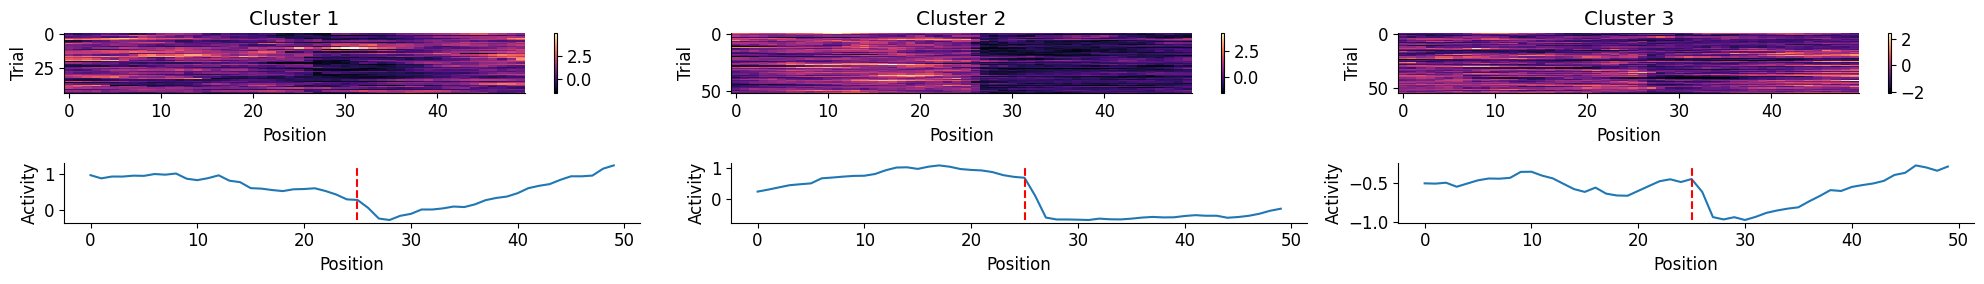

In [90]:
num_neurons = neural_data_tensor.shape[1]
if num_neurons < 20:
    fig, ax = plt.subplots(2*num_neurons, optimal_k, figsize=(20, 3*num_neurons))
    for n in range(num_neurons):
        for k in range(optimal_k):
            cluster_trials = neural_data_tensor[kmeans.labels_==k, n, :]
            im = ax[2*n, k].imshow(cluster_trials, aspect='auto', cmap='magma', interpolation='nearest')
            cbar = fig.colorbar(im, ax=ax[2*n, k])
            ax[2*n, k].set_title(f'Cluster {k+1}')
            ax[2*n, k].set_xlabel('Position')
            ax[2*n, k].set_ylabel('Trial')
            ax[2*n+1, k].plot(cluster_trials.mean(axis=0))
            ax[2*n+1, k].set_xlabel('Position')
            ax[2*n+1, k].set_ylabel('Activity')
            ax[2*n+1, k].vlines(25, cluster_trials.mean(axis=0).min(), cluster_trials.mean(axis=0).max(), color='r', linestyle='--')

    plt.tight_layout()
    plt.show()


In [382]:
num_neurons = neural_data_tensor.shape[1]
if num_neurons > 1:
    # fig, ax = plt.subplots(2, optimal_k, figsize=(15, 3), gridspec_kw={'height_ratios': [3, 1]})
    fig, axes = plt.subplots(1, optimal_k, figsize=(20, 3))
    for k in range(optimal_k):
        cluster_trials = neural_data_tensor[kmeans.labels_==k, :, :]
        neuron_means_in_cluster = cluster_trials.mean(axis=0)  
        if k == 0: # Choose a neuron sorting based on the first cluster
            sorting_idx = neuron_means_in_cluster.argmax(dim=1).sort()[1]
        sorted_neurons = neuron_means_in_cluster[sorting_idx, :]

        # im = ax[0, k].imshow(sorted_neurons, cmap='magma', interpolation='nearest')
        # # im = ax[0, k].imshow(neuron_means_in_cluster, cmap='magma')
        # ax[0, k].set_title(f'Cluster {k+1}')
        # ax[0, k].set_xlabel('Position')
        # ax[0, k].set_ylabel('Neuron')

        ax = axes[k]
        overall_cluster_mean = neuron_means_in_cluster.mean(axis=0)
        ax.plot(overall_cluster_mean)
        ax.set_xlabel('Position')
        ax.set_ylabel('Activity')
        ax.vlines(25, cluster_trials.mean(axis=0).min(), cluster_trials.mean(axis=0).max(), color='r', linestyle='--')
        ax.set_title(f'Cluster {k+1}')
        ax.hlines(0, 0, 50, color='gray', linestyle='--')
    plt.tight_layout()
    plt.show()


In [383]:
w1 = model.vectors[0][0][0,:].detach().numpy()
w2 = model.vectors[0][0][1,:].detach().numpy()
w3 = model.vectors[0][0][2,:].detach().numpy()

# Smooth the weight vectors
import scipy.ndimage as spnd
sigma = 2
w1_smooth = spnd.gaussian_filter1d(w1, sigma=sigma, axis=-1)
w2_smooth = spnd.gaussian_filter1d(w2, sigma=sigma, axis=-1)
w3_smooth = spnd.gaussian_filter1d(w3, sigma=sigma, axis=-1)

# # Make a 3D plot showing the  trajecttories of the three weights across time
# fig = plt.figure()
# ax = fig.add_subplot(111, projection='3d')
# ax.plot(w1_smooth, w2_smooth, w3_smooth)
# ax.set_xlabel('w1')
# ax.set_ylabel('w2')
# ax.set_zlabel('w3')
# ax.view_init(elev=20, azim=45)
# plt.show()

import plotly.graph_objects as go
fig = go.Figure(data=[
                go.Scatter3d(x=w1_smooth, y=w2_smooth, z=w3_smooth, mode='lines', name='trajectory'),
                go.Scatter3d(x=[w1_smooth[0]], y=[w2_smooth[0]], z=[w3_smooth[0]], 
                                mode='markers', marker=dict(color='lime', size=6), name='start'),
                go.Scatter3d(x=[w1_smooth[-1]], y=[w2_smooth[-1]], z=[w3_smooth[-1]], 
                                mode='markers', marker=dict(color='red', size=6), name='end'),])

fig.update_layout(scene = dict(xaxis_title='w1', yaxis_title='w2', zaxis_title='w3'),
                  width=800, height=800)
fig.show()